In [32]:
import numpy as np
import copy
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
#from keras.models import Model, load_model
import pickle
import glob
import numpy.ma as ma # For masked arrays
import imageio


In [33]:
#@title Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
#FUNKCIE

# error image to 2D array with only -1, 0, 1, 2 values
def getErrorsFromPNG(filepath):
  data = cv2.imread(filepath)
  data = data/255
  data = (data[:,:,0]*1 + data[:,:,1]*2 +data[:,:,2]*3)
  # data: 0 = TN, 1 = TP, 2 = FP, 3 = FN (zistit, preco su F naopak) - 
  # 6 - white, 3 - blue, 1 - red
  # data = np.zeros(data.shape,dtype = 'uint8') + (data == 6)*1 + (data == 3)*2 + (data == 1)*3
  # Errors: ('black: 0(TN), white: 2(TP), blue: -1(FN), red: 1(FP)')
  Errors = np.zeros(data.shape)
  Errors += (data==6)*2 + (data==3)*1 + (data==1)*-1

  return Errors


# returns 2 2D arrays (GT - Ground True, predicted)
def reconstructFromErrors(Errors):
  predicted = np.zeros(Errors.shape, dtype='uint8')
  GT = np.zeros(Errors.shape, dtype='uint8')
  predicted = predicted + (Errors==2) + (Errors==1)
  GT = GT + (Errors==2) + (Errors==-1)

  return predicted, GT

In [35]:
Errors = getErrorsFromPNG('/content/drive/MyDrive/School/bioinformatika/results/new_error_54.png') # path to image with errors


In [36]:
predicted, GT = reconstructFromErrors(Errors)
#plt.imshow(GT)

4085


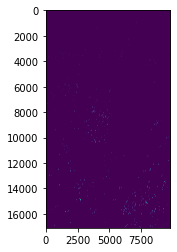

In [37]:
num_labels, labeled_img = cv2.connectedComponents(GT)
plt.imshow(labeled_img)
print(num_labels)

In [38]:
output = cv2.connectedComponentsWithStats(GT, cv2.CC_STAT_AREA, connectivity=8)
# The first cell is the number of labels
# The second cell is the label matrix
# The third cell is the stat matrix
# The fourth cell is the centroid matrix
num_labels = output[0]
stats = output[2]
sizes = stats[1:, 4]
print(num_labels)
print(sizes)
#plt.hist(sizes, density=True, bins=400)

4085
[47 52 38 ... 17  7  6]


In [ ]:
# counts, bins = np.histogram(sizes, range(np.min(sizes),np.max(sizes)+1,1))
# countsCumulative = np.cumsum(counts)
# print('Smallest object: ' + str(np.min(sizes)))
# print('Largest object: ' + str(np.max(sizes)))

In [39]:
def betterHitOrMiss(labeled_img, errors, num_labels):
  no_of_objects = num_labels-1
  hits = np.zeros(no_of_objects,dtype='uint16')
  predicted = np.zeros(errors.shape, dtype='bool')
  predicted = np.logical_or((errors==2),(errors==1))
 
  hit_img = labeled_img*predicted
  hits = np.unique(hit_img, return_counts=True)

  return hits

In [40]:
hits_uniq_freq = betterHitOrMiss(labeled_img, Errors, num_labels)
hit_unique = hits_uniq_freq[0][1:]
hits = hits_uniq_freq[1][1:]
print("Numbers of buildings that were hit")
print(len(hit_unique))
print(list(hit_unique))
print("Number of hit pixels over buildings")
print(len(hits))
print(list(hits))
print("Sizes of labeled buildings:")
print(len(sizes))
print(list(sizes))

Numbers of buildings that were hit
2206
[61, 62, 63, 64, 66, 67, 68, 70, 73, 74, 77, 79, 80, 81, 85, 89, 90, 92, 94, 96, 99, 105, 106, 107, 108, 109, 111, 113, 118, 119, 125, 126, 135, 137, 138, 139, 141, 144, 146, 147, 152, 156, 158, 159, 160, 161, 162, 166, 167, 170, 171, 173, 175, 178, 179, 180, 181, 184, 186, 187, 188, 189, 190, 192, 193, 194, 197, 199, 201, 202, 204, 206, 207, 210, 212, 214, 215, 216, 217, 222, 225, 226, 227, 228, 229, 231, 234, 237, 238, 240, 241, 243, 245, 246, 247, 248, 249, 250, 251, 252, 254, 255, 256, 257, 258, 259, 260, 261, 262, 265, 267, 269, 272, 274, 276, 280, 281, 282, 283, 288, 291, 294, 296, 297, 305, 308, 310, 314, 316, 317, 320, 325, 334, 336, 338, 339, 340, 342, 343, 346, 347, 350, 351, 352, 353, 356, 358, 359, 360, 361, 362, 363, 370, 374, 380, 382, 383, 384, 386, 389, 391, 392, 395, 397, 402, 408, 409, 411, 413, 416, 420, 421, 423, 424, 425, 429, 434, 437, 438, 439, 443, 444, 446, 447, 450, 452, 453, 456, 457, 459, 461, 462, 463, 465, 467, 468, 

In [41]:
print(len(sizes))
hs=hits>0
print(len(hs))

print(len(hits)/len(sizes))

4084
2206
0.5401567091087169


(array([107., 266., 309., 221., 189., 137., 119.,  83.,  74.,  38.,  44.,
         34.,  41.,  19.,  24.,  19.,  12.,  16.,  10.,  11.,   6.,   6.,
          7.,   6.,   6.,   6.,   3.,   8.,   4.,   0.,   1.,   6.,   5.,
          0.,   1.,   1.,   6.,   1.,   4.,   2.,   4.,   1.,   0.,   0.,
          1.,   2.,   0.,   1.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,
          2.,   0.,   2.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   2.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0., 

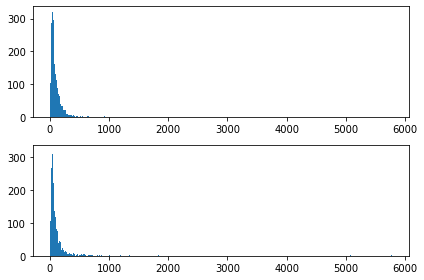

In [42]:
# print(sizes)
# print(hits)
hited_sizes=[]
no_hited_sizes=[]

# This for cycle add 0 to hits, because buildings with 0 hits were lost in np.unique()
hits_with_0 = []
for i in range(len(sizes)):
    if i in hit_unique:
        hits_with_0.append(hits[np.where(hit_unique==i)[0][0]])
    else:
        hits_with_0.append(0)

hits_with_0 = np.array(hits_with_0)
hs=hits_with_0>0

for i in range(len(sizes)):
    if hs[i]:
        hited_sizes.append(sizes[i])
    else:
        no_hited_sizes.append(sizes[i])

#print(hited_sizes)
bns=np.linspace(np.min(sizes),np.max(sizes)+1,num=400)

fig, axs = plt.subplots(2, 1, sharey=True, tight_layout=True)

axs[0].hist(hited_sizes,  bins=bns)
axs[1].hist(no_hited_sizes,  bins=bns)

Text(0.5, 1.0, 'Histogram')

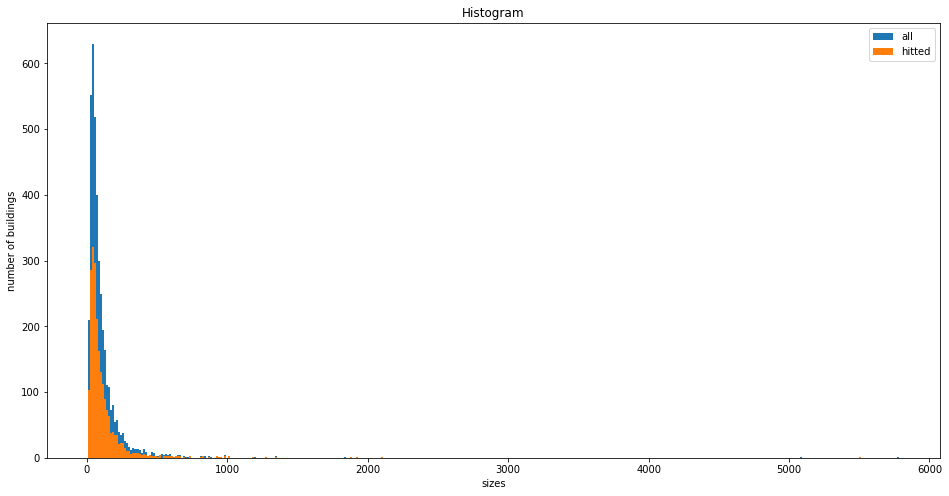

In [43]:
sizes = np.sort(sizes)
bns=np.linspace(np.min(sizes),np.max(sizes)+1,num=400)
leg=['all', 'hited']
plt.figure(figsize=(16,8))
plt.hist(sizes, bins=bns,label='all')
plt.hist(hited_sizes,  bins=bns, label='hitted')
plt.legend(prop={'size': 10})
plt.ylabel('number of buildings')
plt.xlabel('sizes')
plt.title('Histogram')

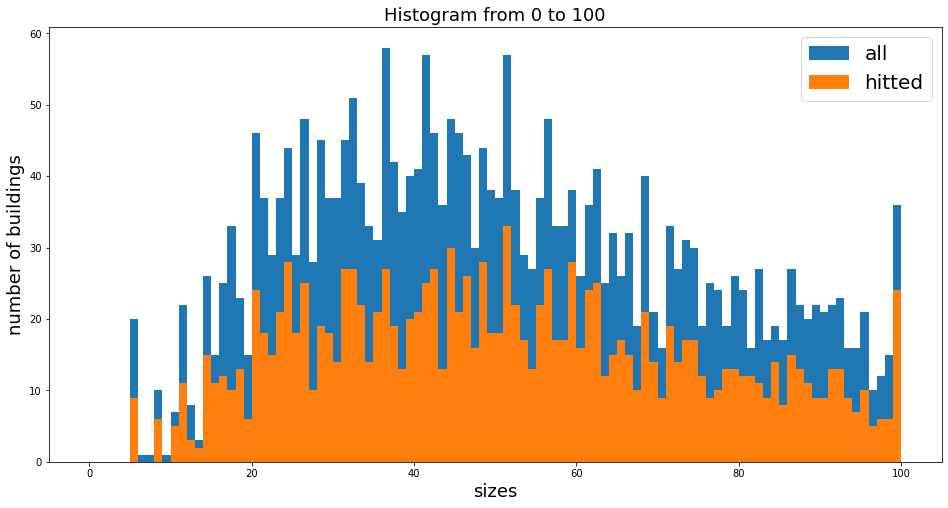

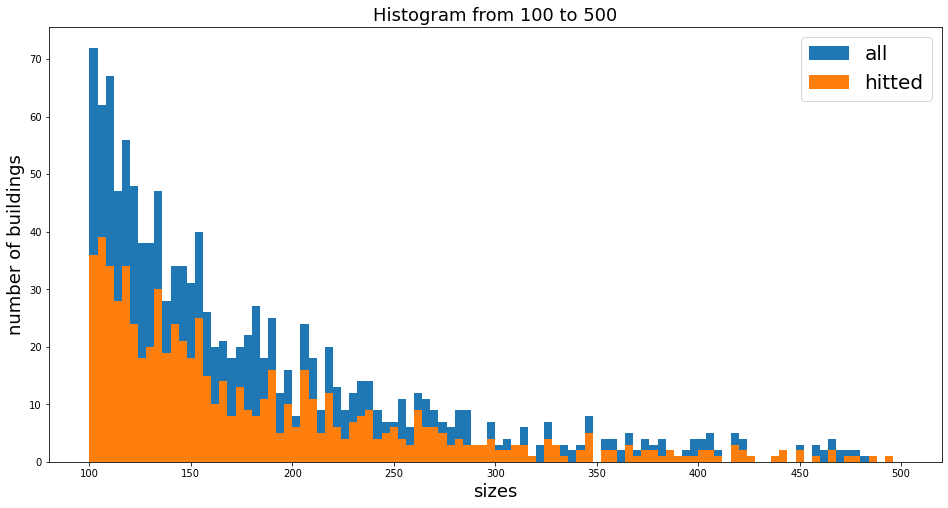

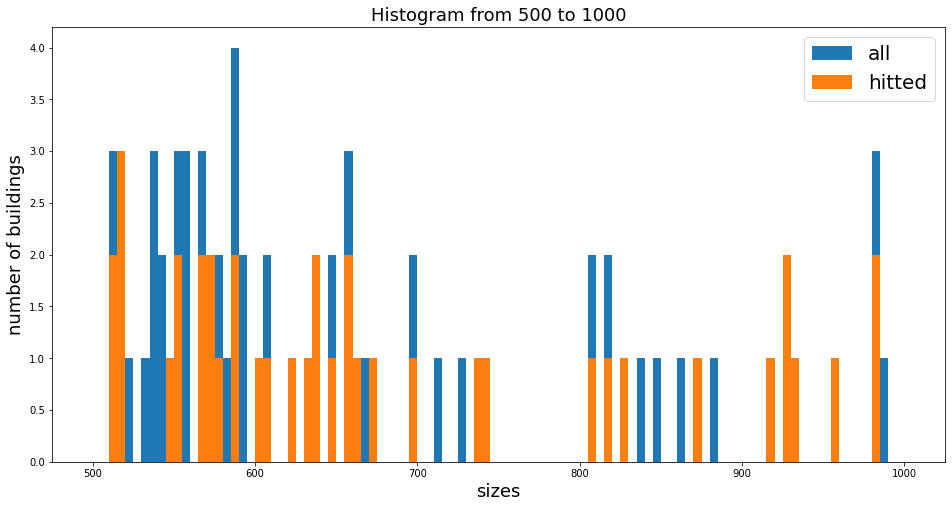

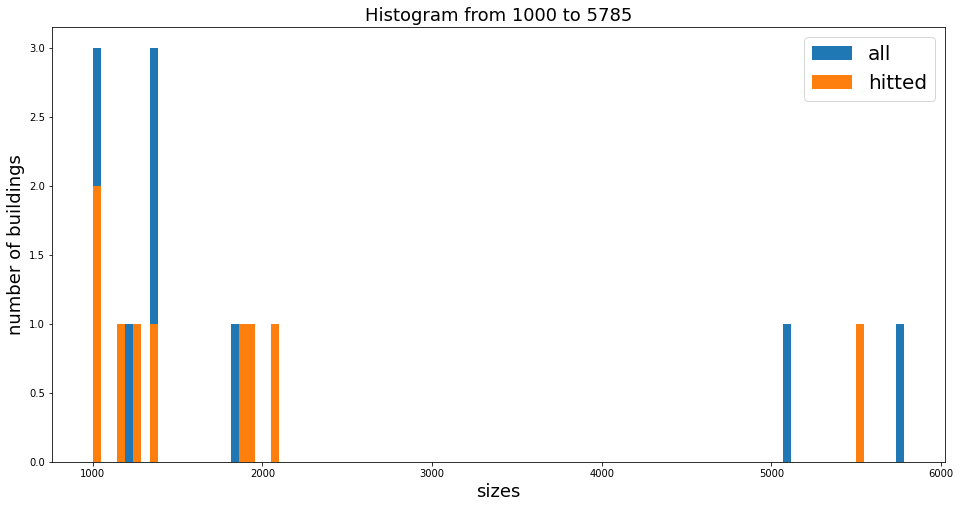

In [49]:
size_array = [0,100,500,1000,np.max(sizes)+1]
bns = 100
for i in range(len(size_array)-1):
  leg=['all', 'hited']
  plt.figure(figsize=(16,8))
  plt.hist(sizes,range=(size_array[i], size_array[i+1]), bins=bns,label='all') # [int(sizes_range[i]):int(sizes_range[i+1])]
  plt.hist(hited_sizes,range=(size_array[i], size_array[i+1]),  bins=bns, label='hitted') # [int(hited_sizes_range[i]):int(hited_sizes_range[i+1])]
  plt.legend(prop={'size': 20})
  plt.ylabel('number of buildings', fontsize=18)
  plt.xlabel('sizes', fontsize=18)
  plt.title('Histogram from {} to {}'.format(size_array[i], size_array[i+1]), fontsize=18)